# 🎌 AniSense — Machine Learning Mini Project
> **Mini Project | Machine Learning**
> **Author:** Himanshu Jadhav
>
> **Problem:** Build a machine-learning application that classifies anime reviews by sentiment and predicts review ratings from text.
>
> This notebook is the **college practical / repository version** of AniSense. The interactive Streamlit application is maintained separately.
>
> ### ML workflow
> `Data → Preprocessing → EDA → Feature Engineering → Train/Test Split → Model Training → Evaluation → Comparison → Inference`


## 1. Objectives

1. Load and inspect a real-world-style anime review dataset.
2. Clean and preprocess review text.
3. Convert text into numerical features using **TF-IDF**.
4. Perform **sentiment classification** using multiple supervised ML algorithms.
5. Perform **rating prediction** as a regression task.
6. Evaluate models using appropriate classification and regression metrics.
7. Compare models and identify the most suitable model for each task.
8. Generate meaningful insights from the trained models.

> **Important methodological note:** sentiment labels are derived from the available ratings, so they are **rating-derived labels**, not independently human-annotated sentiment ground truth.


In [1]:
# Imports and setup
import os
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Environment ready.")


Environment ready.


## 2. Load Dataset

The notebook expects the AniSense data folder to be available at:

`MiniProject_AniSense/data/`

This keeps the notebook suitable for a college repository without depending on absolute local paths.


In [2]:
# Locate the project data directory
CANDIDATE_DIRS = [
    os.path.join("MiniProject_AniSense", "data"),
    os.path.join("..", "MiniProject_AniSense", "data"),
    os.path.join("data")
]

DATA_DIR = next((p for p in CANDIDATE_DIRS if os.path.exists(p)), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Place anime_meta.json and anime_reviews.json "
        "inside MiniProject_AniSense/data/."
    )

with open(os.path.join(DATA_DIR, "anime_reviews.json"), encoding="utf-8") as f:
    raw_reviews = json.load(f)

with open(os.path.join(DATA_DIR, "anime_meta.json"), encoding="utf-8") as f:
    anime_meta = json.load(f)

df = pd.DataFrame(raw_reviews, columns=["anime_title", "rating", "review_text"])
df["genre"] = df["anime_title"].map(lambda t: anime_meta[t]["genre"])

print(f"Reviews loaded : {len(df)}")
print(f"Anime titles   : {df['anime_title'].nunique()}")
print(f"Genres         : {df['genre'].nunique()}")
print(f"Rating range   : {df['rating'].min()} - {df['rating'].max()}")
display(df.head())


Reviews loaded : 126
Anime titles   : 22
Genres         : 6
Rating range   : 2 - 10


,anime_title,rating,review_text,genre
0,Attack on Titan,10,An absolute masterpiece. The storytelling is u...,Action
1,Attack on Titan,9,Brilliant world-building and morally complex c...,Action
2,Attack on Titan,10,The lore is astonishing. Every mystery introdu...,Action
3,Attack on Titan,8,Fantastic anime with incredible action sequenc...,Action
4,Attack on Titan,5,The first two seasons were amazing but the pac...,Action


## 3. Data Quality Checks

Before training, check missing values, duplicates, invalid ratings, and review lengths.


In [3]:
quality = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Unique Values": df.nunique()
})
display(quality)

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate review texts:", df["review_text"].duplicated().sum())
print("Invalid ratings:", (~df["rating"].between(1, 10)).sum())

df["review_length"] = df["review_text"].str.len()
print("\nReview length statistics:")
display(df["review_length"].describe())


,Missing Values,Unique Values
anime_title,0,22
rating,0,9
review_text,0,126
genre,0,6


Duplicate rows: 0
Duplicate review texts: 0
Invalid ratings: 0

Review length statistics:


count    126.000000
mean     164.253968
std       13.424119
min      131.000000
25%      156.000000
50%      163.000000
75%      169.000000
max      201.000000
Name: review_length, dtype: float64

## 4. Create the Target Variable

For sentiment classification, ratings are mapped to three classes:

- **Positive:** 9–10
- **Neutral:** 6–8
- **Negative:** below 6

This is a transparent rule-based label derived from the rating field.


In [4]:
def rating_to_sentiment(rating):
    if rating >= 9:
        return "Positive"
    elif rating >= 6:
        return "Neutral"
    return "Negative"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

print("Sentiment distribution:")
display(df["sentiment"].value_counts().to_frame("count"))

print("\nSentiment percentages:")
display((df["sentiment"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))


Sentiment distribution:


,count
sentiment,
Positive,62
Neutral,47
Negative,17



Sentiment percentages:


,percentage
sentiment,
Positive,49.21
Neutral,37.30
Negative,13.49


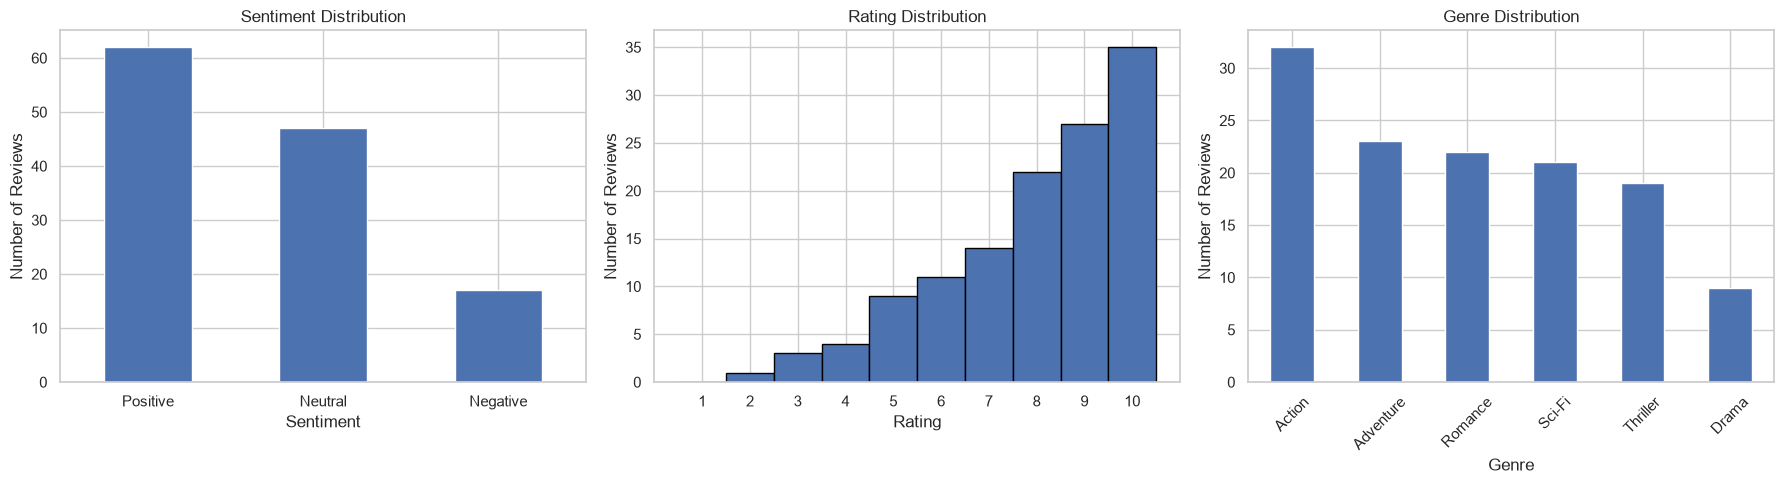

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["sentiment"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Reviews")
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(df["rating"], bins=np.arange(0.5, 11.5, 1), edgecolor="black")
axes[1].set_title("Rating Distribution")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks(range(1, 11))

df["genre"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Genre Distribution")
axes[2].set_xlabel("Genre")
axes[2].set_ylabel("Number of Reviews")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 5. Text Preprocessing

The review text is normalized before feature extraction:

1. Lowercasing
2. URL removal
3. Removal of non-alphabetic characters
4. Whitespace normalization
5. Tokenization
6. Stop-word removal
7. Lemmatization


In [6]:
import nltk
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet"]:
    nltk.download(resource, quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [
        LEMMATIZER.lemmatize(token)
        for token in tokens
        if token not in STOP_WORDS and len(token) > 2
    ]
    return " ".join(tokens)

df["clean_review"] = df["review_text"].apply(preprocess)

display(df[["review_text", "clean_review"]].head(5))


,review_text,clean_review
0,An absolute masterpiece. The storytelling is u...,absolute masterpiece storytelling unparalleled...
1,Brilliant world-building and morally complex c...,brilliant world building morally complex chara...
2,The lore is astonishing. Every mystery introdu...,lore astonishing every mystery introduced seas...
3,Fantastic anime with incredible action sequenc...,fantastic anime incredible action sequence sto...
4,The first two seasons were amazing but the pac...,first two season amazing pacing slows noticeab...


## 6. TF-IDF Feature Engineering

TF-IDF converts each review into a numerical feature vector.

We use:

- unigrams + bigrams (`ngram_range=(1,2)`)
- sublinear term frequency
- a bounded vocabulary

The vectorizer is fitted **only on the training data** to avoid test-set leakage.


In [7]:
X_text = df["clean_review"]
y_class = df["sentiment"]
y_rating = df["rating"]

X_train_text, X_test_text, y_train_class, y_test_class, y_train_rating, y_test_rating = train_test_split(
    X_text,
    y_class,
    y_rating,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_class
)

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix :", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.get_feature_names_out()))


Training matrix: (100, 2229)
Testing matrix : (26, 2229)
Vocabulary size: 2229


# Part A — Sentiment Classification

We compare three classical ML algorithms widely used for text classification:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine


In [8]:
classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.5),
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=3000)
}

classification_results = []
trained_classifiers = {}

for name, model in classifiers.items():
    model.fit(X_train_tfidf, y_train_class)
    predictions = model.predict(X_test_tfidf)
    trained_classifiers[name] = model

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_class, predictions),
        "Precision (Macro)": precision_score(y_test_class, predictions, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test_class, predictions, average="macro", zero_division=0),
        "F1 (Macro)": f1_score(y_test_class, predictions, average="macro", zero_division=0),
        "F1 (Weighted)": f1_score(y_test_class, predictions, average="weighted", zero_division=0)
    })

classification_results_df = pd.DataFrame(classification_results).sort_values(
    "F1 (Macro)", ascending=False
)

display(classification_results_df.round(4))


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted)
2,Linear SVM,0.6923,0.4566,0.5154,0.4841,0.6493
1,Logistic Regression,0.6923,0.4722,0.5077,0.4803,0.6435
0,Multinomial Naive Bayes,0.6923,0.4575,0.5077,0.4772,0.6429


## 7.1 Classification Reports

Accuracy alone can hide poor performance on minority classes, so precision, recall and F1-score are also examined.


In [9]:
for name, model in trained_classifiers.items():
    predictions = model.predict(X_test_tfidf)
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_test_class, predictions, zero_division=0))


Multinomial Naive Bayes
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
     Neutral       0.67      0.60      0.63        10
    Positive       0.71      0.92      0.80        13

    accuracy                           0.69        26
   macro avg       0.46      0.51      0.48        26
weighted avg       0.61      0.69      0.64        26

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
     Neutral       0.75      0.60      0.67        10
    Positive       0.67      0.92      0.77        13

    accuracy                           0.69        26
   macro avg       0.47      0.51      0.48        26
weighted avg       0.62      0.69      0.64        26

Linear SVM
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
     Neutral       0.64      0.70      0.67        10
    Positive       0

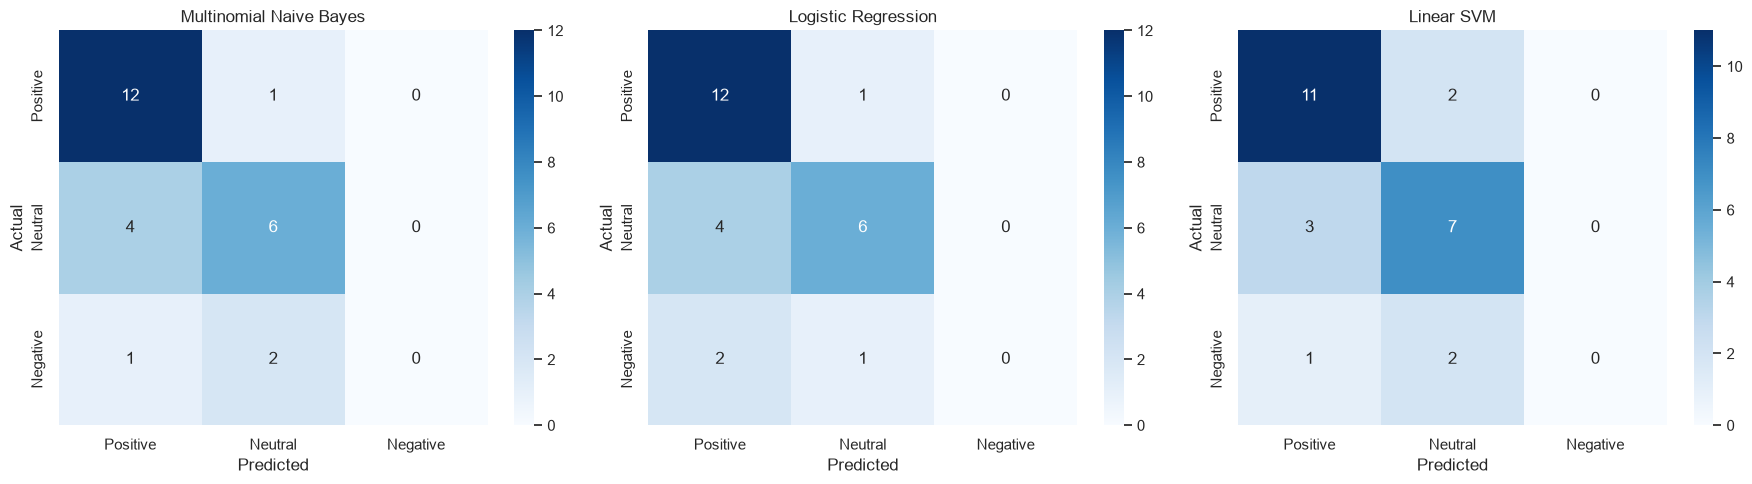

In [10]:
# Confusion matrices
label_order = ["Positive", "Neutral", "Negative"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_classifiers.items()):
    predictions = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test_class, predictions, labels=label_order)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_order, yticklabels=label_order, ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 7.2 Cross-Validation

The hold-out test set gives one estimate of generalization. To reduce dependence on one split, we also perform **5-fold stratified cross-validation** using a Pipeline so that TF-IDF is refitted inside each training fold.


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for name, model in classifiers.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=3000, sublinear_tf=True)),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_text,
        y_class,
        cv=cv,
        scoring=["accuracy", "f1_macro", "f1_weighted"],
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV F1 Macro Mean": scores["test_f1_macro"].mean(),
        "CV F1 Weighted Mean": scores["test_f1_weighted"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV F1 Macro Mean", ascending=False)
display(cv_results_df.round(4))


,Model,CV Accuracy Mean,CV Accuracy Std,CV F1 Macro Mean,CV F1 Weighted Mean
2,Linear SVM,0.6031,0.0363,0.4114,0.5504
0,Multinomial Naive Bayes,0.5714,0.0466,0.3770,0.5081
1,Logistic Regression,0.5628,0.0606,0.3442,0.4699


## 7.3 Interpreting Logistic Regression Features

For linear text models, coefficients indicate which features push predictions toward particular classes. These are **model associations**, not causal explanations.


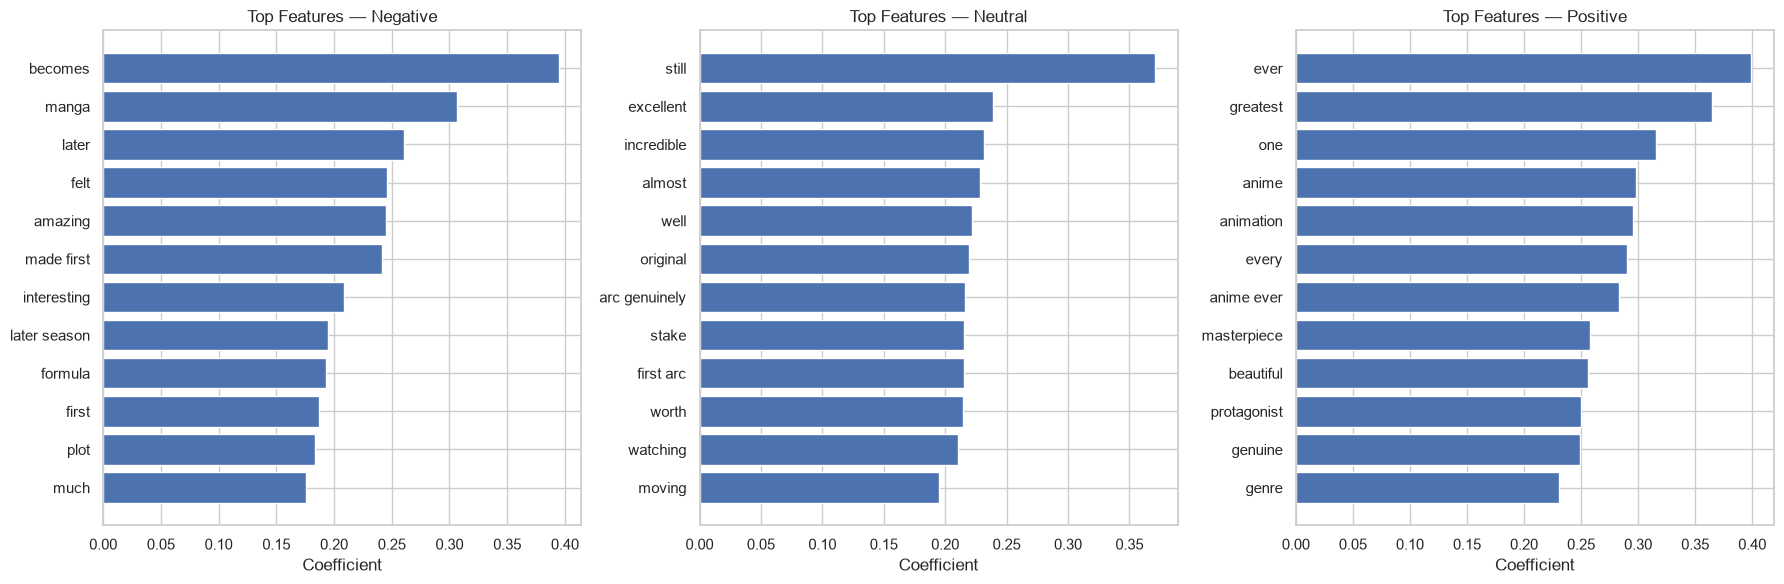

In [12]:
lr = trained_classifiers["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cls in zip(axes, lr.classes_):
    idx = list(lr.classes_).index(cls)
    coefficients = lr.coef_[idx]
    top_idx = np.argsort(coefficients)[-12:]

    ax.barh(feature_names[top_idx], coefficients[top_idx])
    ax.set_title(f"Top Features — {cls}")
    ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.show()


# Part B — Rating Prediction

The same review text can also be treated as a regression problem.

**Input:** review text  
**Target:** numerical rating from 1 to 10

We compare:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Metrics:

- MAE
- RMSE
- R²


In [13]:
regressors = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, min_samples_leaf=2, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE
    )
}

regression_results = []
trained_regressors = {}

for name, model in regressors.items():
    model.fit(X_train_tfidf, y_train_rating)
    predictions = model.predict(X_test_tfidf)
    trained_regressors[name] = model

    regression_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_rating, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_rating, predictions)),
        "R2": r2_score(y_test_rating, predictions)
    })

regression_results_df = pd.DataFrame(regression_results).sort_values("MAE")
display(regression_results_df.round(4))


,Model,MAE,RMSE,R2
0,Linear Regression,1.0648,1.3297,0.4459
2,Gradient Boosting,1.1516,1.4929,0.3015
1,Random Forest,1.3011,1.6203,0.1772


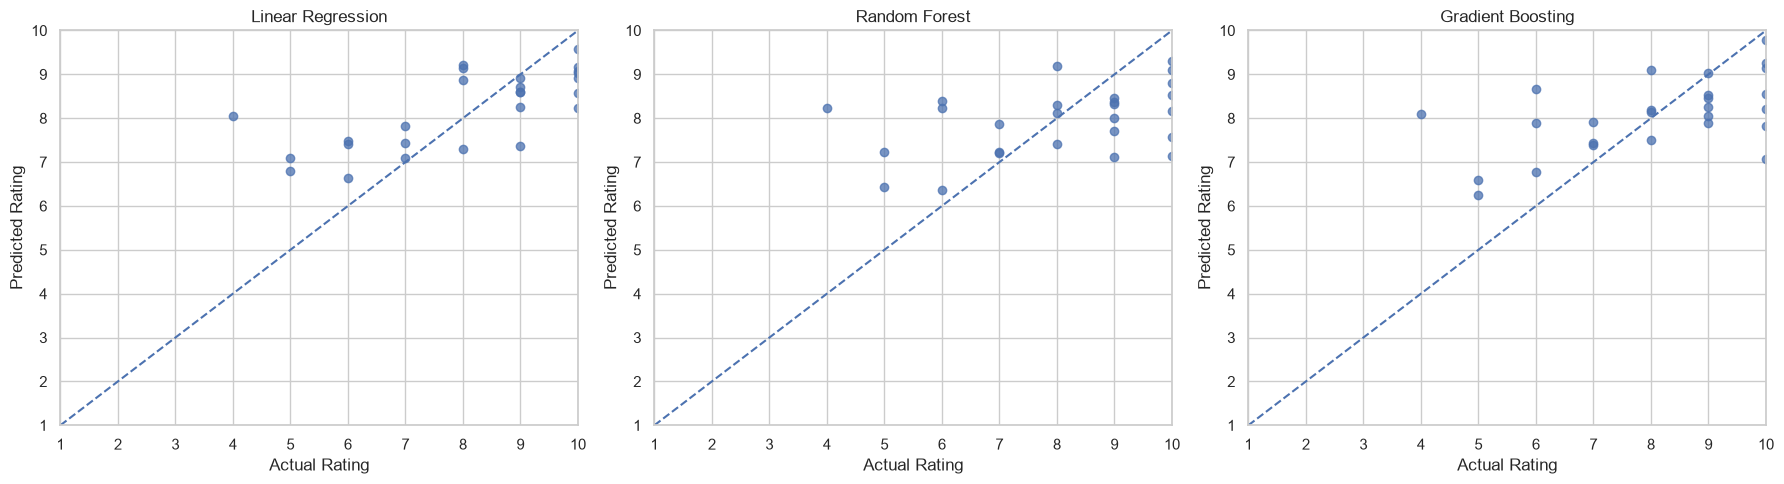

In [14]:
# Actual vs predicted ratings for each regression model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_regressors.items()):
    predictions = model.predict(X_test_tfidf)

    ax.scatter(y_test_rating, predictions, alpha=0.75)
    ax.plot([1, 10], [1, 10], linestyle="--")
    ax.set_xlim(1, 10)
    ax.set_ylim(1, 10)
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(name)

plt.tight_layout()
plt.show()


## 8. Regression Cross-Validation

Five-fold cross-validation is repeated for the regression task. Lower MAE/RMSE and higher R² indicate better predictive performance.


In [15]:
reg_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
reg_cv_rows = []

for name, model in regressors.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=3000, sublinear_tf=True)),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_text,
        y_rating,
        cv=reg_cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
        n_jobs=-1
    )

    reg_cv_rows.append({
        "Model": name,
        "CV MAE Mean": -scores["test_neg_mean_absolute_error"].mean(),
        "CV RMSE Mean": -scores["test_neg_root_mean_squared_error"].mean(),
        "CV R2 Mean": scores["test_r2"].mean()
    })

reg_cv_results_df = pd.DataFrame(reg_cv_rows).sort_values("CV MAE Mean")
display(reg_cv_results_df.round(4))


,Model,CV MAE Mean,CV RMSE Mean,CV R2 Mean
0,Linear Regression,1.1597,1.5305,0.3562
2,Gradient Boosting,1.3049,1.6839,0.2211
1,Random Forest,1.3228,1.7384,0.1696


# Part C — Text Similarity Recommendation

The recommendation component is an **unsupervised/content-based similarity method**, not a supervised classifier.

Anime reviews are aggregated by title, represented with TF-IDF, and compared using cosine similarity.


In [16]:
anime_corpus = df.groupby("anime_title")["clean_review"].apply(" ".join)

anime_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=500
)

anime_matrix = anime_vectorizer.fit_transform(anime_corpus)
similarity_matrix = cosine_similarity(anime_matrix)

anime_titles = list(anime_corpus.index)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=anime_titles,
    columns=anime_titles
)

def recommend(anime_name, top_n=5):
    if anime_name not in similarity_df.index:
        raise ValueError(f"Unknown anime: {anime_name}")

    scores = similarity_df.loc[anime_name].drop(anime_name).sort_values(ascending=False)
    return scores.head(top_n).rename("Similarity").reset_index().rename(
        columns={"index": "Anime"}
    )

query_title = anime_titles[0]
print(f"Recommendations for: {query_title}")
display(recommend(query_title))


Recommendations for: Anohana


,Anime,Similarity
0,Clannad After Story,0.205634
1,Your Lie in April,0.126188
2,Violet Evergarden,0.112605
3,Steins;Gate,0.107697
4,Naruto,0.095284


# Part D — Final Inference Demo

The following function demonstrates how the trained ML models can be used on a new review.

This is the same prediction logic that can be connected to the separate Streamlit interface.


In [17]:
# Select models using the cross-validation comparisons
best_classifier_name = cv_results_df.iloc[0]["Model"]
best_regressor_name = reg_cv_results_df.iloc[0]["Model"]

best_classifier = trained_classifiers[best_classifier_name]
best_regressor = trained_regressors[best_regressor_name]

def anisense_predict(review):
    clean = preprocess(review)
    vector = tfidf.transform([clean])

    sentiment = best_classifier.predict(vector)[0]
    predicted_rating = float(np.clip(best_regressor.predict(vector)[0], 1, 10))

    return {
        "Predicted Sentiment": sentiment,
        "Predicted Rating": round(predicted_rating, 2),
        "Classification Model": best_classifier_name,
        "Regression Model": best_regressor_name
    }

sample_review = (
    "The animation was incredible and the characters were memorable, "
    "although the story became repetitive near the end."
)

anisense_predict(sample_review)


{'Predicted Sentiment': 'Positive',
 'Predicted Rating': 7.8,
 'Classification Model': 'Linear SVM',
 'Regression Model': 'Linear Regression'}

# 9. Final Results Summary

The final model choice should be based on the **cross-validation results**, not simply the best score from one test split.

### Classification
Use **macro F1** as an important comparison metric because it gives each sentiment class equal weight.

### Regression
Use **MAE** as the most directly interpretable error measure, alongside RMSE and R².

### Recommendation
Cosine similarity provides content-based anime recommendations from review language.

> Because the dataset is small and sentiment labels are derived from ratings, results should be interpreted as an educational ML experiment rather than a production-grade sentiment benchmark.


In [18]:
print("=== ANISENSE FINAL SUMMARY ===\n")

print("Sentiment classification — 5-fold CV:")
display(cv_results_df.round(4))

print("\nRating regression — 5-fold CV:")
display(reg_cv_results_df.round(4))

print(f"\nSelected classification model: {best_classifier_name}")
print(f"Selected regression model    : {best_regressor_name}")
print(f"Dataset size                : {len(df)} reviews")
print(f"Anime coverage              : {df['anime_title'].nunique()} titles")


=== ANISENSE FINAL SUMMARY ===

Sentiment classification — 5-fold CV:


,Model,CV Accuracy Mean,CV Accuracy Std,CV F1 Macro Mean,CV F1 Weighted Mean
2,Linear SVM,0.6031,0.0363,0.4114,0.5504
0,Multinomial Naive Bayes,0.5714,0.0466,0.3770,0.5081
1,Logistic Regression,0.5628,0.0606,0.3442,0.4699



Rating regression — 5-fold CV:


,Model,CV MAE Mean,CV RMSE Mean,CV R2 Mean
0,Linear Regression,1.1597,1.5305,0.3562
2,Gradient Boosting,1.3049,1.6839,0.2211
1,Random Forest,1.3228,1.7384,0.1696



Selected classification model: Linear SVM
Selected regression model    : Linear Regression
Dataset size                : 126 reviews
Anime coverage              : 22 titles


# 10. Conclusion

AniSense demonstrates a complete classical machine-learning workflow on text data.

### Machine Learning techniques demonstrated

- Data cleaning and quality checks
- Feature engineering with TF-IDF
- Supervised classification
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM
- Supervised regression
- Linear Regression
- Random Forest Regression
- Gradient Boosting Regression
- Train/test evaluation
- Stratified 5-fold cross-validation
- Classification metrics
- Regression metrics
- Confusion matrices
- Model feature interpretation
- Content-based recommendation using cosine similarity

### NLP connection

The project also demonstrates the NLP pipeline required to convert natural language into machine-learning features:

`Text → Cleaning → Tokenization → Lemmatization → TF-IDF → ML`

Therefore, the same AniSense project can be presented for **NLP** with emphasis on language processing and for **Machine Learning** with emphasis on feature engineering, model training, comparison and evaluation.

### Limitations

- Small review dataset
- Rating-derived sentiment labels
- No independently human-annotated sentiment ground truth
- Recommendation quality is limited by the available anime corpus
- Results may vary with a larger and more diverse dataset

### Future Scope

- Expand the review dataset
- Add independently annotated sentiment labels
- Compare TF-IDF with transformer embeddings
- Add collaborative filtering
- Add aspect-based sentiment analysis
- Integrate live anime/review data into the separate Streamlit application
